# df_interpolator_tutorial

**Interpolating Missing Data with tspropy**

This tutorial demonstrates how to use `tspropy`'s powerful `interpolate_df` function to handle missing data in time-series datasets. We'll explore various interpolation strategies, limits, and methods.

## 1. Setup and Data Loading

First, let's import the necessary libraries and load our sample dataset containing missing values.

In [12]:
import pandas as pd

from src.data_manipulation.core.advanced.df_interpolator import interpolate_df
from src.data_manipulation.custom_objects.phase_duration import PhaseDuration
from src.data_manipulation.custom_objects.plotter_objects import Labels
from src.plotters.plotly_plotters import plot_datetime_data

In [15]:
# Load the dataset with missing values
# The dataset contains 3 columns: 2 numerical ("Grid Load" and "PV Generation") and 1 non-numerical
df = pd.read_csv(
    r"..\..\data\dataset_with_missing_data.csv",
    index_col="datetime",
    parse_dates=True,
)

# Display the first few rows to understand the data structure
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
                           Grid Load non-numerical column  PV Generation
datetime                                                                
2017-12-28 00:00:00+00:00       5.89                    a            0.0
2017-12-28 00:15:00+00:00       5.81                    a            0.0
2017-12-28 00:30:00+00:00       5.74                    a            0.0
2017-12-28 00:45:00+00:00       5.73                    a            0.0
2017-12-28 01:00:00+00:00       5.78                    a            0.0


In [ ]:
# Visualize the original dataset to see the missing data patterns
fig1 = plot_datetime_data(
    df=df, 
    labels=Labels(y1_label="Load in MW"), 
    title="Original Dataset with Missing Values"
)

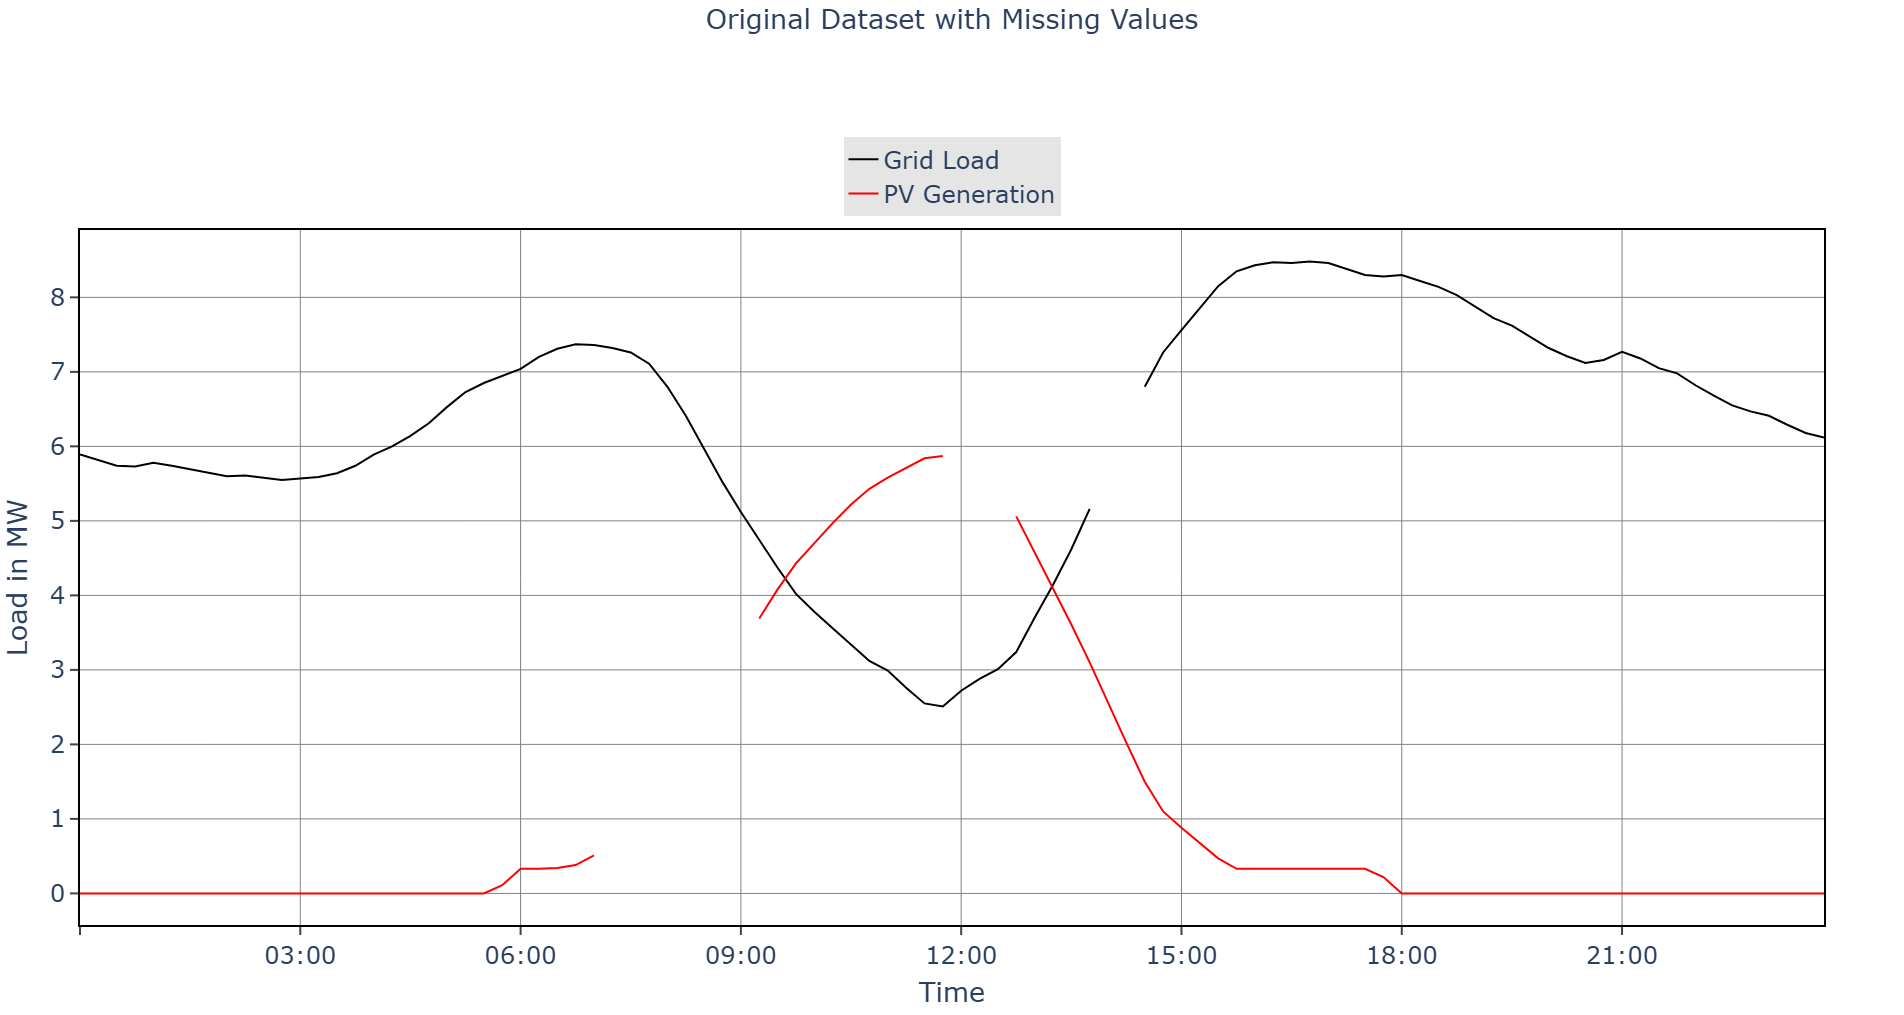

## 2. Understanding Interpolation Methods

This section compares pandas' built-in interpolation with tspropy's enhanced version.

| Feature                             | `pandas.DataFrame.interpolate()`                                    | `tspropy.interpolate_df()`                                                          |
| ----------------------------------- | ------------------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| **Primary purpose**                 | General-purpose filling of missing values                           | Controlled interpolation for time-series data                                       |
| **Per-column methods**              | ⚠️ Requires separate operations / manual logic                      | ✅ `methods_mapper` allows different methods per column                              |
| **Per-column limits**               | ⚠️ Possible, but requires separate calls / logic                    | ✅ `limits_mapper`                                                                   |
| **Default method**                  | `linear`                                                            | `time`                                                                              |
| **Maximum gap size**                | ✅ `limit` controls the number of consecutive NaNs filled            | ✅ Gap length can be evaluated using time-series duration                            |
| **Long gaps**                       | ⚠️ Can partially fill a long gap depending on `limit` and direction | **✅ Skips the entire long gap**                                                     |
| **Time-duration-based gap control** | ❌ `limit` is primarily a number of consecutive observations         | ✅ Designed around actual time duration / `PhaseDuration`                            |
| **NaN statistics**                  | ❌                                                                   | ✅ Provides interpolation statistics/results                                         |
| **Validation of columns/mappings**  | Limited                                                             | ✅ Validates mappings against the DataFrame and interpolatable columns               |
| **Explicit interpolation mask**     | ❌                                                                   | ✅ Tracks which values are eligible for interpolation                                |
| **API abstraction**                 | Low-level pandas operation                                          | Higher-level time-series utility                                                    |
| **Best suited for**                 | Simple/general NaN filling                                          | Sensor/energy/time-series preprocessing where **large gaps must not be fabricated** |


### The important difference: long gaps

This is the strongest reason to use `tspropy.interpolate_df()` instead of calling `df.interpolate()` directly.

Given a 15-minute time series:

```text
08:00    10.0
08:15    10.5
08:30     NaN
08:45     NaN
09:00     NaN
09:15     NaN
09:30     NaN
09:45     NaN
10:00    20.0
```

Let the maximum acceptable interpolation gap is **30 minutes**.

The missing period is **1.5 hours**, so it should be considered too large to interpolate.

With `tspropy.interpolate_df()`, the **whole gap is skipped**:

```text
08:00    10.0
08:15    10.5
08:30     NaN
08:45     NaN
09:00     NaN
09:15     NaN
09:30     NaN
09:45     NaN
10:00    20.0
```

With pandas, using something like:

```python
df.interpolate(limit=2)
```

means pandas is allowed to fill **up to two consecutive NaNs**. The beginning of a longer gap can therefore still be filled:

```text
08:00    10.0
08:15    10.5
08:30    11.86   ← filled
08:45    13.21   ← filled
09:00     NaN
09:15     NaN
09:30     NaN
09:45     NaN
10:00    20.0
```

### Why this matters for time-series data

For something like **energy-meter or sensor data**, this distinction is significant.

A 15-minute missing value between two measurements might be reasonable to interpolate:

```text
10.0 ─── NaN ─── 11.0
          ↑
      reasonable
```

But if the sensor was offline for six hours:

```text
10.0 ─── NaN ─── NaN ─── NaN ─── ... ─── 11.0
                  ↑
          should remain missing
```

Filling the beginning of that six-hour outage can give the false impression that the data quality is better than it actually is.


### The InterpolationResult Object

The `InterpolationResult` object returned by `interpolate_df()` contains three key components:

1. **interpolated_df**: The DataFrame with interpolated values
2. **interpolation_mask**: A boolean mask indicating which cells were interpolated (True = interpolated)
3. **nan_statistics**: Summary of NaN counts before and after interpolation

## 3. Basic Interpolation (Default Settings)

In this first use case, we apply the default "time" interpolation method to all numerical columns without any limits.
 The non-numerical column is automatically preserved. limit parameter is None (interpolates all gaps regardless of
 size).

In [18]:
# Simple interpolation with default settings
interpolation_result1 = interpolate_df(df=df)

In [ ]:
fig2 = plot_datetime_data(
    df=interpolation_result1.interpolated_df,
    labels=Labels(y1_label="Load in MW"),
    title="Default Interpolation (No Limit, time Method)"
)

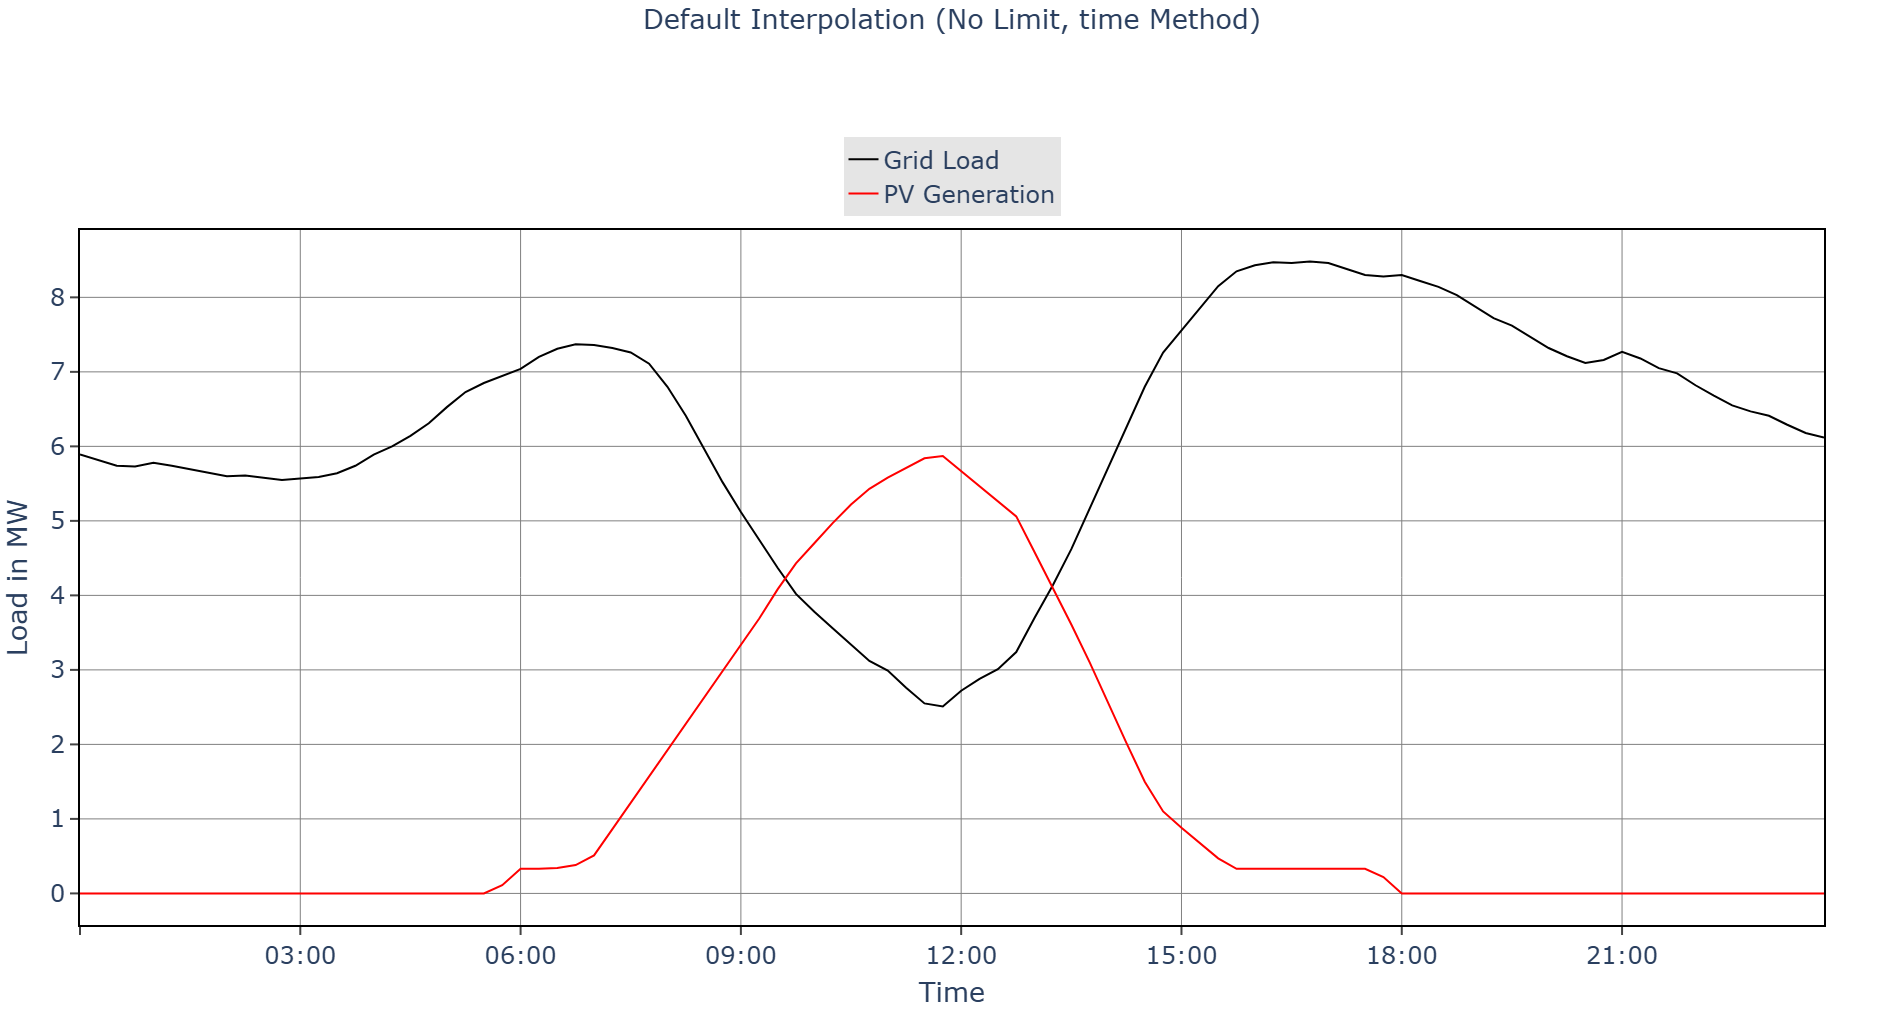

In [20]:
# Compare a specific time range before and after interpolation
print("Original Data (2017-12-28 13:30 to 15:00):")
print(df.loc["2017-12-28 13:30":"2017-12-28 15:00"])
print("\nInterpolated Data:")
print(interpolation_result1.interpolated_df.loc["2017-12-28 13:30":"2017-12-28 15:00"])

3. Original Data (2017-12-28 13:30 to 15:00):
                           Grid Load non-numerical column  PV Generation
datetime                                                                
2017-12-28 13:30:00+00:00       4.62                    a           3.61
2017-12-28 13:45:00+00:00       5.16                    a           3.10
2017-12-28 14:00:00+00:00        NaN                    a           2.55
2017-12-28 14:15:00+00:00        NaN                    a           2.02
2017-12-28 14:30:00+00:00       6.80                    a           1.50
2017-12-28 14:45:00+00:00       7.26                    a           1.10
2017-12-28 15:00:00+00:00       7.56                    a           0.88

Interpolated Data:
                           Grid Load non-numerical column  PV Generation
datetime                                                                
2017-12-28 13:30:00+00:00   4.620000                    a           3.61
2017-12-28 13:45:00+00:00   5.160000                    a 

In [21]:
# Display the interpolation mask
# True = value was interpolated, False = original value
print("Interpolation Mask (2017-12-28 13:30 to 15:00):")
print(interpolation_result1.interpolation_mask.loc["2017-12-28 13:30":"2017-12-28 15:00"])

4. Interpolation Mask (2017-12-28 13:30 to 15:00):
                           Grid Load  non-numerical column  PV Generation
datetime                                                                 
2017-12-28 13:30:00+00:00      False                 False          False
2017-12-28 13:45:00+00:00      False                 False          False
2017-12-28 14:00:00+00:00       True                 False          False
2017-12-28 14:15:00+00:00       True                 False          False
2017-12-28 14:30:00+00:00      False                 False          False
2017-12-28 14:45:00+00:00      False                 False          False
2017-12-28 15:00:00+00:00      False                 False          False


In [22]:
# View the NaN statistics
print("NaN Statistics Before and After Interpolation:")
print(interpolation_result1.nan_statistics)

5. NaN Statistics Before and After Interpolation:
{'Grid Load': NanStatistics(original=2, filled=2, remaining=0), 'non-numerical column': NanStatistics(original=12, filled=0, remaining=12), 'PV Generation': NanStatistics(original=11, filled=11, remaining=0)}


## 4. Advanced Use Cases

### Case A: Per-Column Interpolation Limits

This example demonstrates how to set different interpolation limits for each column using `PhaseDuration`. The "PV Generation" column will only interpolate gaps of up to 1 hour, while "Grid Load" has no limit.

In [23]:
# Apply different interpolation limits per column
interpolation_result2 = interpolate_df(
    df=df,
    limits_mapper={
        "PV Generation": PhaseDuration("1h"),
        # No limit specified for "Grid Load"
    },
)

In [ ]:
# Visualize the result
fig3 = plot_datetime_data(
    df=interpolation_result2.interpolated_df,
    labels=Labels(y1_label="Load in MW"),
    title="Interpolation with 1h Limit for PV Generation"
)

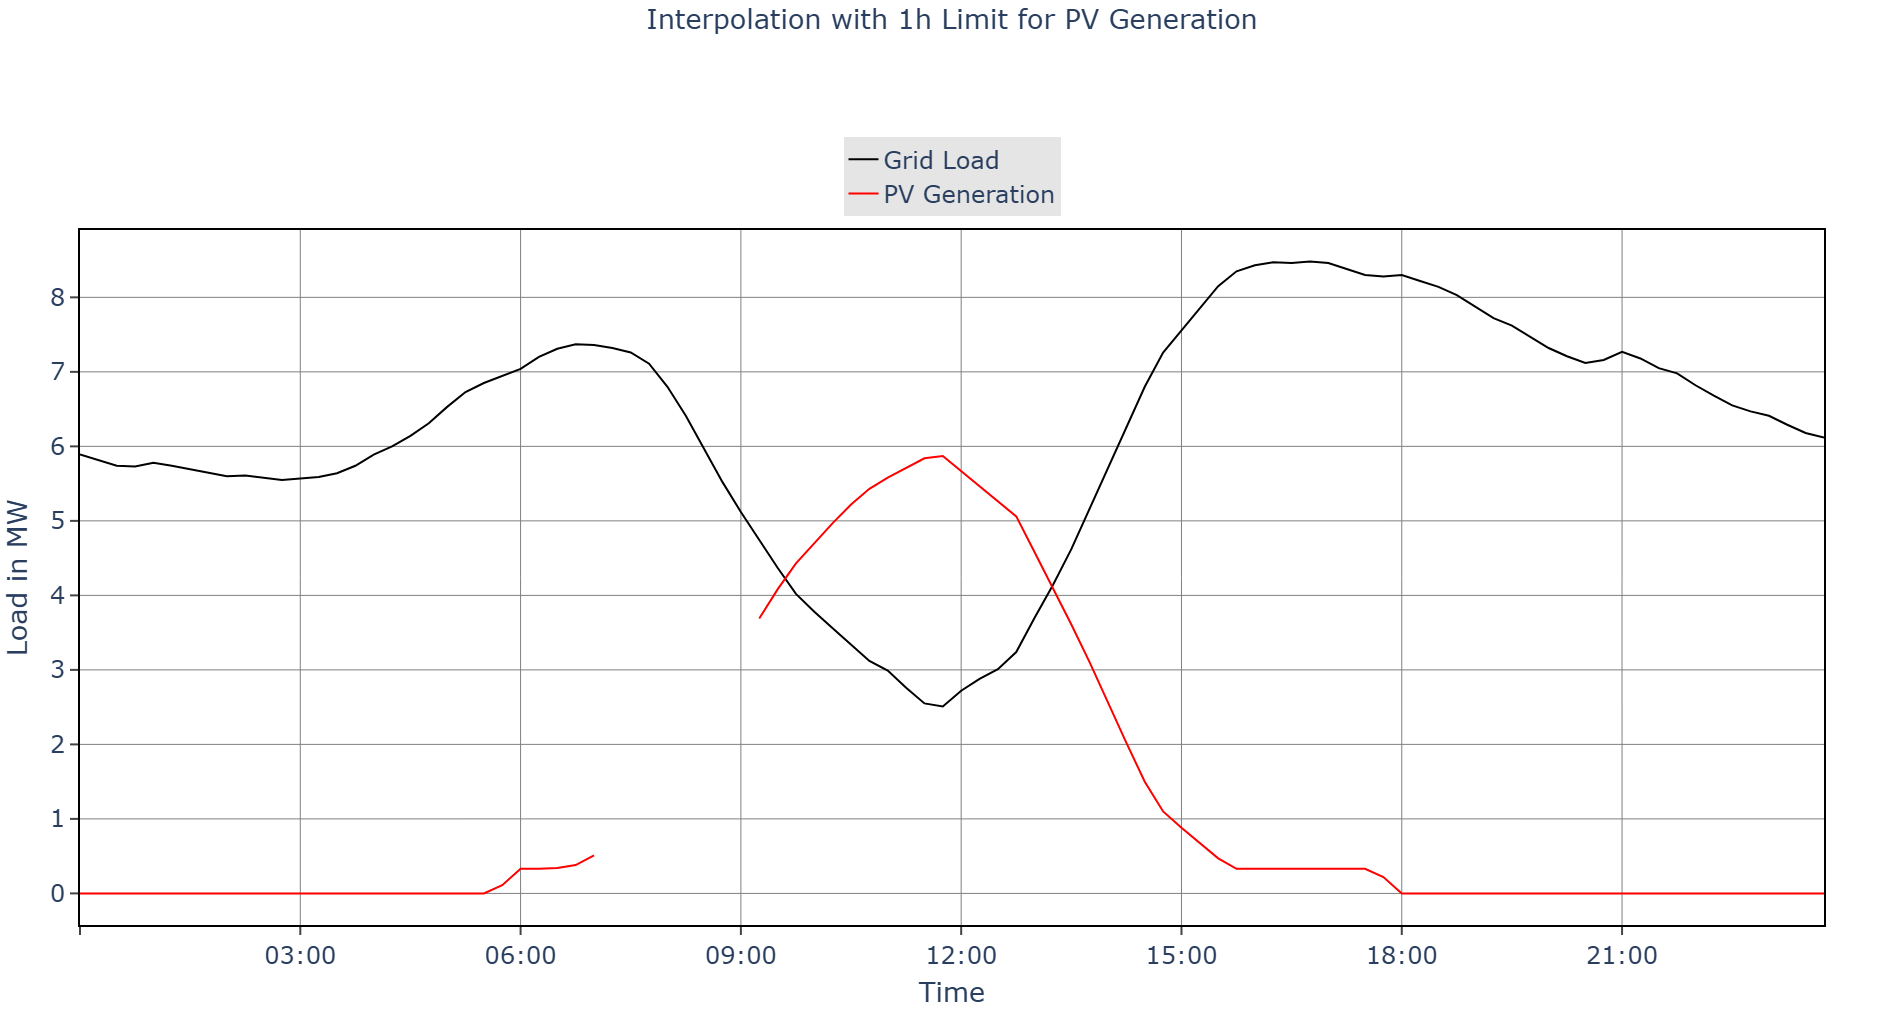

In [25]:
# Check the NaN statistics to see the effect of the limit
print("NaN Statistics with 1h Limit for PV Generation:")
print(interpolation_result2.nan_statistics)

7. NaN Statistics with 1h Limit for PV Generation:
{'Grid Load': NanStatistics(original=2, filled=2, remaining=0), 'non-numerical column': NanStatistics(original=12, filled=0, remaining=12), 'PV Generation': NanStatistics(original=11, filled=3, remaining=8)}


### Case B: Different Interpolation Methods Per Column

Here we apply different interpolation methods to each column. "PV Generation" uses linear interpolation while "Grid Load" uses cubic interpolation.

In [26]:
# Apply different interpolation methods per column
interpolation_result3 = interpolate_df(
    df=df,
    methods_mapper={
        "PV Generation": "linear",
        "Grid Load": "cubic",
    },
)

In [ ]:
# Visualize the result with different methods
fig4 = plot_datetime_data(
    df=interpolation_result3.interpolated_df,
    labels=Labels(y1_label="Load in MW"),
    title="Interpolation with Different Methods (Linear for PV, Cubic for Grid)"
)

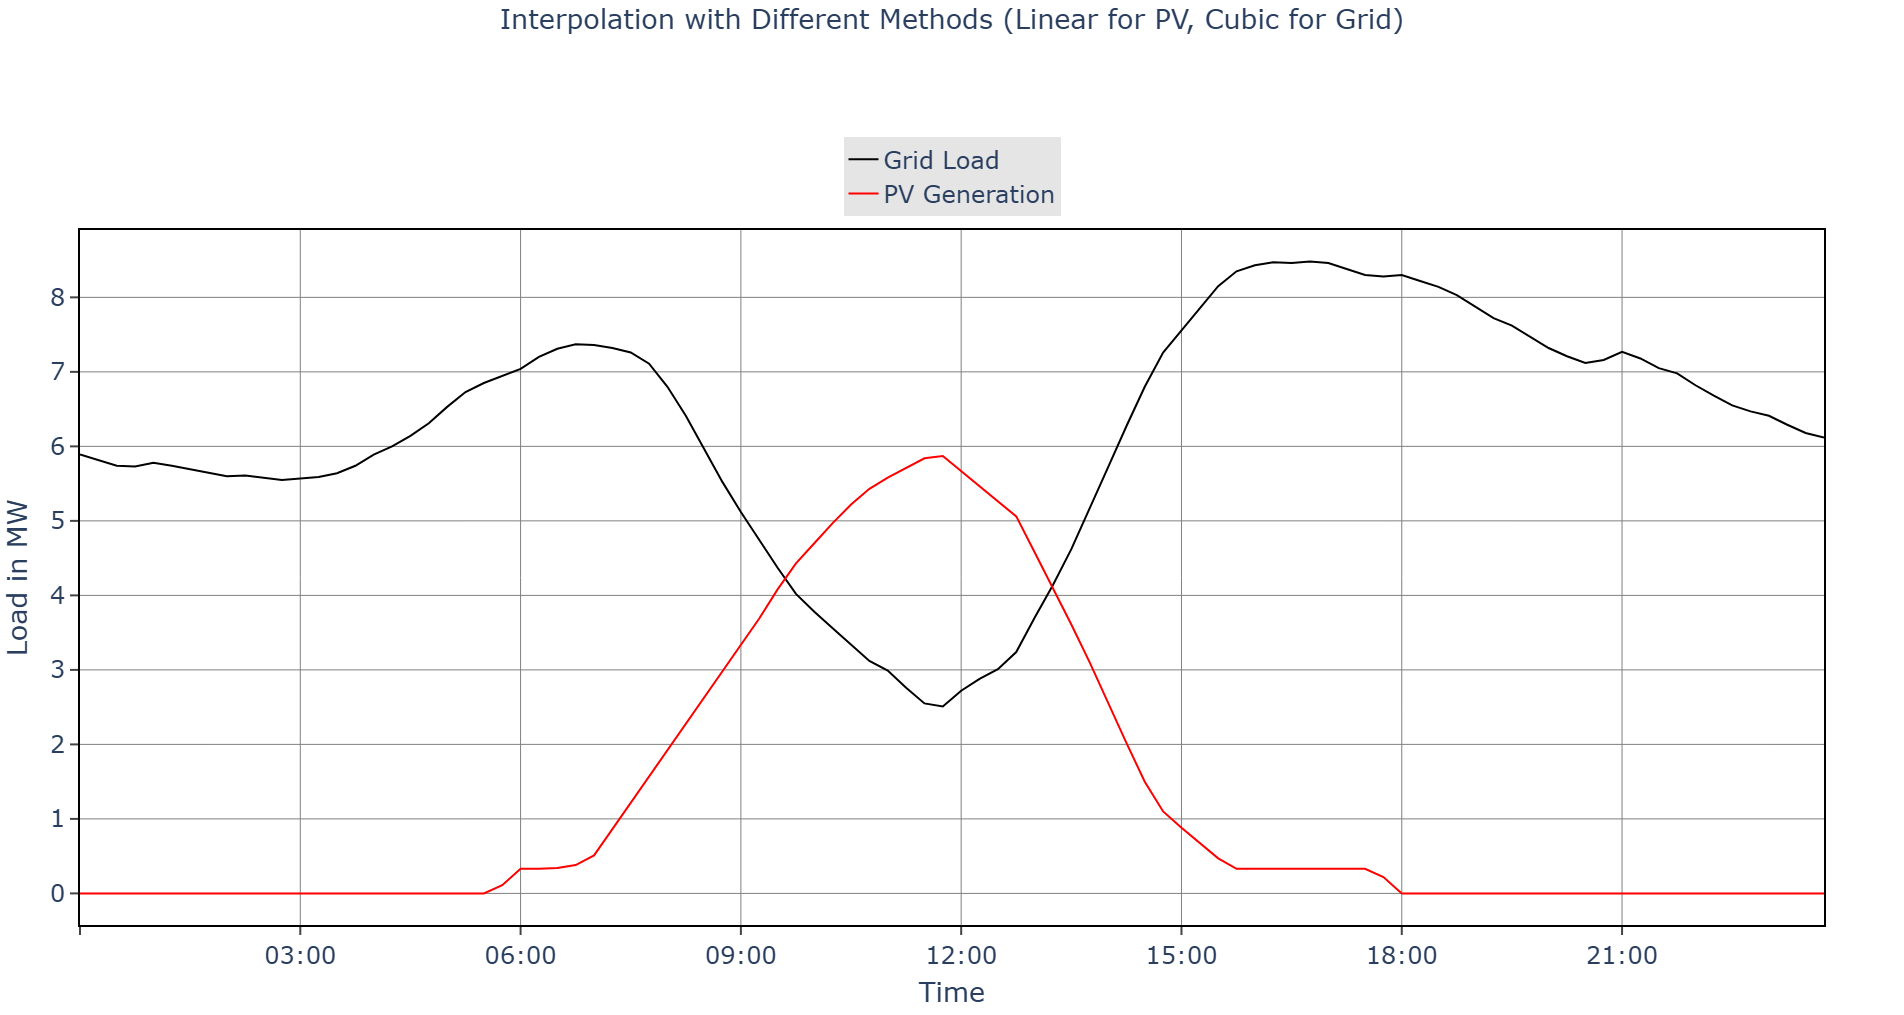

In [28]:
# Compare the interpolation results for a specific gap
print("Comparison of Interpolation Methods (2017-12-28 13:30 to 15:00):")
print("Linear interpolation for PV Generation:")
print(interpolation_result3.interpolated_df.loc["2017-12-28 13:30":"2017-12-28 15:00", "PV Generation"])
print("\nCubic interpolation for Grid Load:")
print(interpolation_result3.interpolated_df.loc["2017-12-28 13:30":"2017-12-28 15:00", "Grid Load"])

9. Comparison of Interpolation Methods (2017-12-28 13:30 to 15:00):
Linear interpolation for PV Generation:
datetime
2017-12-28 13:30:00+00:00    3.61
2017-12-28 13:45:00+00:00    3.10
2017-12-28 14:00:00+00:00    2.55
2017-12-28 14:15:00+00:00    2.02
2017-12-28 14:30:00+00:00    1.50
2017-12-28 14:45:00+00:00    1.10
2017-12-28 15:00:00+00:00    0.88
Name: PV Generation, dtype: float64

Cubic interpolation for Grid Load:
datetime
2017-12-28 13:30:00+00:00    4.620000
2017-12-28 13:45:00+00:00    5.160000
2017-12-28 14:00:00+00:00    5.717635
2017-12-28 14:15:00+00:00    6.269768
2017-12-28 14:30:00+00:00    6.800000
2017-12-28 14:45:00+00:00    7.260000
2017-12-28 15:00:00+00:00    7.560000
Name: Grid Load, dtype: float64
